# DATA ANALYSIS MATHEMATICS, ALGORITHMS & MODELING (PROG8431)
## Group Presentation 1 – Exploring Safety Metrics for Autonomous Taxis

**Team 3**

| # | Name              | Student ID |
|---|-------------------|------------|
| 1 | Sultan Atanda     | 9114837    |
| 2 | Ricardo Mohammed  | 7500382    |
| 3 | Alamir Ibrahim    | 9104960    |

**GitHub Repository:** [paste your repo link here]

---

## The Problem & Research Question

Autonomous vehicles (AVs) are being deployed as robotaxis across U.S. cities. Regulators, manufacturers, and the public need clear evidence on **what kinds of incidents occur and under what conditions**.

**Research Question**  
> Which environmental and roadway factors are most associated with RoboTaxi crashes?

We treat **Crash Interaction Type** (Motor Vehicle, Fixed Object, Non-Motorist) as the target variable.

**Why it matters**
- Public safety – identifies high-risk scenarios
- Regulation – informs oversight priorities
- Engineering – highlights edge cases for developers

---

## Data Source

**Source:** NHTSA Standing General Order (SGO) 2021-01  
**File:** `SGO-2021-01_Incident_Reports_ADS.csv`  
**Raw size:** 1,365 incident reports × 116 columns  
**Scope:** Autonomous vehicle incidents reported by 16 manufacturers

**Answer to “Questions to Consider for Choosing Data” (slide 20):**  
The data is publicly available, regularly updated by a federal agency, contains both structured fields and free-text narratives, and directly addresses real-world AV safety – making it ideal for continued analysis in later assignments.

---


## Environment Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


class EnvironmentSetup:
    """Applies the warning, pandas and seaborn settings used across the notebook."""

    def __init__(self, max_rows=100, theme_style="whitegrid", font_scale=1.0):
        self.max_rows = max_rows
        self.theme_style = theme_style
        self.font_scale = font_scale

    def apply(self):
        warnings.filterwarnings("ignore")

        # Display settings
        pd.set_option("display.max_columns", None)
        pd.set_option("display.max_rows", self.max_rows)

        # Plot settings
        sns.set_theme(style=self.theme_style, font_scale=self.font_scale)

        print("Libraries loaded successfully.")
        return self


EnvironmentSetup().apply()

Libraries loaded successfully.


# Load the Data

In [2]:
DATA_PATH = "SGO-2021-01_Incident_Reports_ADS.csv"


class IncidentDataLoader:
    """Loads the raw SGO incident file and provides quick summary views of it."""

    def __init__(self, path):
        self.path = path
        self.df = None

    def load(self):
        self.df = pd.read_csv(self.path)

        print(f"Number of rows: {self.df.shape[0]:,}")
        print(f"Number of columns: {self.df.shape[1]:,}")

        display(self.df.head())
        return self.df

    def info(self):
        print("\nDataset Information:")
        self.df.info()

    def describe_numeric(self):
        return self.df.describe().T

    def describe_categorical(self):
        return self.df.describe(include="object").T


loader = IncidentDataLoader(DATA_PATH)
df = loader.load()

Number of rows: 1,365
Number of columns: 116


,Report ID,Report Version,Reporting Entity,Report Type,Report Month,Report Year,Report Submission Date,VIN,VIN Decoded,Serial Number,Make,Make - Unknown,Model,Model - Unknown,Model Year,Model Year - Unknown,Same Vehicle ID,Driver / Operator Type,Automation Feature Version,Automation Feature Version CBI,Automation System Engaged?,Engagement Status,Operating Entity,Operating Entity - Unknown,Source - Complaint/Claim,Source - Telematics,Source - Law Enforcement,Source - Field Report,Source - Testing,Source - Media,Source - Internal Process Review,Source - NHTSA VOQ,Source - Other - See Narrative,Source - Other Entity,Source - State or Other Agency,Incident Date,Incident Date - Unknown,Incident Time (24:00),Incident Time - Unknown,Same Incident ID,Latitude,Latitude - Unknown,Longitude,Longitude - Unknown,Address,Address - Unknown,City,City - Unknown,State,Zip Code,Zip Code - Unknown,Roadway Type,Roadway-Degraded Surface,Roadway-Missing/Degraded Marking,Roadway-No Unusual Conditions,Roadway-Other-See Narrative,Roadway-Traffic Incident,Roadway-Unknown,Roadway-Wet Surface Condition,Roadway-Work Zone,Weather - Clear,Weather - Snow,Weather - Cloudy,Weather - Partly Cloudy,Weather - Fog/Smoke/Haze,Weather - Rain,Weather - Severe Wind,Weather - Dust Storm,Weather - Severe Hurricane,Weather - Structure-Indoor,Weather - Unk - See Narrative,Crash With,Highest Injury Severity Alleged,CP Pre-Crash Movement,CP Contact Area - Rear Left,CP Contact Area - Left,CP Contact Area - Front Left,CP Contact Area - Rear,CP Contact Area - Top,CP Contact Area - Front,CP Contact Area - Rear Right,CP Contact Area - Right,CP Contact Area - Front Right,CP Contact Area - Bottom,CP Contact Area - Unknown,SV Pre-Crash Movement,Any Air Bags Deployed?,Was Any Vehicle Towed?,Were All Passengers Belted?,SV Precrash Speed (MPH),SV Pre-crash Speed - Unknown,SV Contact Area - Rear Left,SV Contact Area - Left,SV Contact Area - Front Left,SV Contact Area - Rear,SV Contact Area - Top,SV Contact Area - Front,SV Contact Area - Rear Right,SV Contact Area - Right,SV Contact Area - Front Right,SV Contact Area - Bottom,SV Contact Area - Unknown,Data Availability - EDR,Data Availability - Police Rpt,Data Availability - Telematics,Data Availability - Complaints,Data Availability - Video,Data Availability - Other,Data Availability - No Data,Data Availability - Unknown,Investigating Agency,Investigating Agency - Unknown,Within ODD?,Within ODD? - CBI,Narrative,Narrative - CBI?
0,30270-15818,1,Waymo LLC,5-Day,NaN,NaN,JUL-2026,SADHW2S19M1,Y,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],JAGUAR,,I-PACE,,2021,,4edb4192b29d35b,In-Vehicle (Commercial / Test),"5th Generation ADS, Version 11",,ADS,Verified Engaged,Waymo LLC,,,Y,,,,,,,,,,JUN-2026,,23:41,,23e5092fb203585,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,San Francisco,,CA,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,Intersection,,,Y,,,,,,Y,,,,,,,,,,,Passenger Car,Property Damage. No Injured Reported,Entering Traffic,,,Y,,,,,,,,,Proceeding Straight,"No Subject Vehicle, No Crash Partner","No Subject Vehicle, No Crash Partner",Subject Vehicle - All Belted,7,,,,,,,Y,,,,,,,,Y,,Y,,,,NaN,,Yes,,"On June [XXX], 2026 at 11:41 PM PT a Waymo Aut...",
1,31101-15391,1,Avride Inc.,Monthly,6.0,2026.0,JUL-2026,7YAKN4DA3TY,Y,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],HYUNDAI,,Ioniq 5,,2026,,ad80ff4deb77ab6,In-Vehicle (Commercial / Test),RC-04-17,,ADS,Verified Engaged,Avride Inc,,,Y,,Y,,,,,,,,JUN-2026,,14:23,,3f049fd1f212039,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,Dallas,,TX,[MAY CONTAIN PERSONALLY IDENTIFIABLE INFORMATION],,Street,,,Y,,,,,,Y,,,,,,,,,,,SUV,Property Damage. No Injured Reported,Changing Lanes,,Y,,,,,,,,,,Proceeding Straight,"No Subject Vehicle, No Crash Partner","No Subject Vehicle, No Crash Partner",Subj

In [3]:
loader.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Columns: 116 entries, Report ID to Narrative - CBI?
dtypes: float64(2), int64(3), object(111)
memory usage: 1.2+ MB


## 5. Descriptive Statistics

In [4]:
loader.describe_numeric()

,count,mean,std,min,25%,50%,75%,max
Report Version,1365.0,1.038828,0.249548,1.0,1.0,1.0,1.0,5.0
Report Month,639.0,6.251956,3.339334,1.0,4.0,6.0,9.0,12.0
Report Year,639.0,2025.544601,0.498397,2025.0,2025.0,2026.0,2026.0,2026.0
Model Year,1365.0,2023.936996,1.130289,2017.0,2024.0,2024.0,2024.0,2026.0
SV Precrash Speed (MPH),1365.0,6.213919,10.325549,0.0,0.0,0.0,9.0,65.0


In [5]:
loader.describe_categorical()

,count,unique,top,freq
Report ID,1365,1324,31101-13612,5
Reporting Entity,1365,16,Waymo LLC,1125
Report Type,1365,3,5-Day,685
Report Submission Date,1365,14,MAY-2026,137
VIN,1365,139,SADHW2S15R1,115
...,...,...,...,...
Investigating Agency - Unknown,1365,2,,1348
Within ODD?,1365,4,Yes,1333
Within ODD? - CBI,1365,2,,1335
Narrative,1365,1344,"[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS I...",19


# 6. Data Cleaning

### Cleaning class
All cleaning and feature-engineering steps are methods of `AVIncidentCleaner`. The reason for each step is documented in the markdown above it and in the method's docstring.

In [6]:
class AVIncidentCleaner:

    ADMIN_REPORT_COLUMNS = [
        'Report ID',
        'Report Type',
        'Report Month',
        'Report Year',
        'Report Submission Date',
    ]

    VEHICLE_ID_COLUMNS = [
        'VIN',
        'VIN Decoded',
        'Serial Number',
        'Same Vehicle ID',
        'Driver / Operator Type',
    ]

    UNKNOWN_INDICATOR_COLUMNS = [
        'Make - Unknown',
        'Model - Unknown',
        'Model Year - Unknown',
        'Operating Entity - Unknown',
        'Incident Date - Unknown',
        'Incident Time - Unknown',
        'Latitude - Unknown',
        'Longitude - Unknown',
        'Address - Unknown',
        'City - Unknown',
        'Zip Code - Unknown',
        'Roadway-Unknown',
        'Weather - Unk - See Narrative',
        'SV Pre-crash Speed - Unknown',
    ]

    INVESTIGATION_COLUMNS = [
        'Investigating Agency',
        'Investigating Agency - Unknown',
    ]

    CBI_COLUMNS = [
        'Narrative - CBI?',
        'Automation Feature Version CBI',
        'Within ODD? - CBI',
    ]

    NARRATIVE_COLUMNS = [
        'Narrative',
        'Roadway-Other-See Narrative',
    ]

    SOURCE_COLUMNS = [
        'Source - Complaint/Claim',
        'Source - Telematics',
        'Source - Law Enforcement',
        'Source - Field Report',
        'Source - Testing',
        'Source - Media',
        'Source - Internal Process Review',
        'Source - NHTSA VOQ',
        'Source - Other - See Narrative',
        'Source - Other Entity',
        'Source - State or Other Agency',
    ]

    SEVERITY_COLUMNS = [
        'Highest Injury Severity Alleged',
        'Any Air Bags Deployed?',
        'Was Any Vehicle Towed?',
        'Were All Passengers Belted?',
    ]

    CONTACT_AREA_COLUMNS = [
        'CP Contact Area - Rear Left',
        'CP Contact Area - Left',
        'CP Contact Area - Front Left',
        'CP Contact Area - Rear',
        'CP Contact Area - Top',
        'CP Contact Area - Front',
        'CP Contact Area - Rear Right',
        'CP Contact Area - Right',
        'CP Contact Area - Front Right',
        'CP Contact Area - Bottom',
        'CP Contact Area - Unknown',
        'SV Contact Area - Rear Left',
        'SV Contact Area - Left',
        'SV Contact Area - Front Left',
        'SV Contact Area - Rear',
        'SV Contact Area - Top',
        'SV Contact Area - Front',
        'SV Contact Area - Rear Right',
        'SV Contact Area - Right',
        'SV Contact Area - Front Right',
        'SV Contact Area - Bottom',
        'SV Contact Area - Unknown',
    ]

    DATA_AVAILABILITY_COLUMNS = [
        'Data Availability - EDR',
        'Data Availability - Police Rpt',
        'Data Availability - Telematics',
        'Data Availability - Complaints',
        'Data Availability - Video',
        'Data Availability - Other',
        'Data Availability - No Data',
        'Data Availability - Unknown',
    ]

    RECORD_ID_COLUMNS = [
        'Report Version',
        'Reporting Entity',
        'Same Incident ID',
    ]

    LOCATION_COLUMNS = [
        'Latitude',
        'Longitude',
        'Address',
        'Zip Code',
    ]

    DATE_TIME_COLUMNS = [
        'Incident Date',
        'Incident Time (24:00)',
    ]

    SYSTEM_ID_COLUMNS = [
        'Engagement Status',
        'Operating Entity',
        'Model',
        'Automation Feature Version',
    ]

    ROADWAY_CONDITIONS = {
        'Roadway-Degraded Surface': 'Degraded Surface',
        'Roadway-Missing/Degraded Marking': 'Missing/Degraded Marking',
        'Roadway-Traffic Incident': 'Traffic Incident',
        'Roadway-Wet Surface Condition': 'Wet Surface',
        'Roadway-Work Zone': 'Work Zone',
    }

    WEATHER_CONDITIONS = {
        'Weather - Clear': 'Clear',
        'Weather - Snow': 'Snow',
        'Weather - Cloudy': 'Cloudy',
        'Weather - Partly Cloudy': 'Partly Cloudy',
        'Weather - Fog/Smoke/Haze': 'Fog/Smoke/Haze',
        'Weather - Rain': 'Rain',
        'Weather - Severe Wind': 'Severe Wind',
        'Weather - Dust Storm': 'Dust Storm',
        'Weather - Severe Hurricane': 'Severe Hurricane',
        'Weather - Structure-Indoor': 'Structure/Indoor',
    }

    MOTOR_VEHICLE_TYPES = [
        "Passenger Car",
        "SUV",
        "Pickup Truck",
        "Heavy Truck",
        "Van",
        "Bus",
        "Motorcycle",
        "First Responder Vehicle",
    ]

    NON_MOTORIST_TYPES = [
        "Non-Motorist: Pedestrian",
        "Non-Motorist: Cyclist",
        "Non-Motorist: Scooter - Skateboard",
        "Non-Motorist: Other",
        "Animal",
    ]

    FIXED_OBJECT_TYPES = [
        "Other Fixed Object",
        "Pole / Tree",
    ]

    def __init__(self, df):
        self.df = df.copy()

    def _drop(self, columns, label):
        self.df = self.df.drop(columns=columns)
        print(f"{label} removed.")
        print("Remaining columns:", len(self.df.columns))
        return self

    def drop_administrative_columns(self):
        """Reason: these columns describe the report itself, not the robo-taxi incident."""
        return self._drop(self.ADMIN_REPORT_COLUMNS, "Administrative columns")

    def drop_vehicle_identification_columns(self):
        """Reason: identifiers, not useful for analysing incident causes or severity."""
        return self._drop(self.VEHICLE_ID_COLUMNS, "Vehicle identification columns")

    def drop_unknown_indicator_columns(self):
        """Reason: they only flag unknown values, which are handled in the original columns."""
        return self._drop(self.UNKNOWN_INDICATOR_COLUMNS, "Redundant unknown-indicator columns")

    def drop_investigation_columns(self):
        """Reason: they describe the investigating agency, not the incident itself."""
        return self._drop(self.INVESTIGATION_COLUMNS, "Investigation-related columns")

    def drop_cbi_metadata(self):
        """Reason: administrative confidential-business-information flags."""
        return self._drop(self.CBI_COLUMNS, "CBI metadata")

    def drop_narrative_columns(self):
        """Reason: analysing free text would require NLP; we focus on structured data."""
        return self._drop(self.NARRATIVE_COLUMNS, "Narrative column")

    def drop_source_columns(self):
        """Reason: they describe how the incident was reported, not what contributed to it."""
        return self._drop(self.SOURCE_COLUMNS, "Incident source / reporting columns")

    def drop_severity_columns(self):
        """Reason: they describe consequences, not factors behind what the taxi crashed with."""
        return self._drop(self.SEVERITY_COLUMNS, "Crash severity and post-crash outcome columns")

    def drop_contact_area_columns(self):
        """Reason: they describe where contact occurred, not the conditions of the crash."""
        return self._drop(self.CONTACT_AREA_COLUMNS, "Crash contact-area columns")

    def drop_data_availability_columns(self):
        """Reason: they describe which evidence existed, not crash contributing factors."""
        return self._drop(self.DATA_AVAILABILITY_COLUMNS, "Data availability columns")

    def drop_record_identification_columns(self):
        """Reason: they identify the record / reporter / database structure."""
        return self._drop(
            self.RECORD_ID_COLUMNS,
            "Administrative and record-identification columns",
        )

    def drop_location_columns(self):
        """Reason: exact coordinates and addresses are too specific for general factors."""
        return self._drop(self.LOCATION_COLUMNS, "Exact location and address columns")

    def drop_date_time_columns(self):
        """Reason: unnecessary granularity that does not directly explain crash type."""
        return self._drop(self.DATE_TIME_COLUMNS, "Incident date and time columns")

    def drop_system_identification_columns(self):
        """Reason: manufacturer / operator identifiers may introduce selection bias."""
        return self._drop(
            self.SYSTEM_ID_COLUMNS,
            "Vehicle and operational identification columns",
        )

    def _roadway_label(self, row):
        conditions = []

        for column, label in self.ROADWAY_CONDITIONS.items():
            if row[column] == "Y":
                conditions.append(label)

        if not conditions:
            if row["Roadway-No Unusual Conditions"] == "Y":
                return "No Unusual Conditions"
            else:
                return "Unknown"

        return "; ".join(conditions)

    def combine_roadway_conditions(self):
        """Merge the roadway flag columns into one ``Roadway_Conditions`` feature."""
        self.df["Roadway_Conditions"] = self.df.apply(self._roadway_label, axis=1)

        print("Roadway condition columns combined.")
        print("New column created: Roadway_Conditions")


        original_columns = list(self.ROADWAY_CONDITIONS) + ["Roadway-No Unusual Conditions"]
        self.df = self.df.drop(columns=original_columns)

        print("Original roadway condition columns removed.")
        print("Remaining columns:", len(self.df.columns))
        return self

    def _weather_label(self, row):
        conditions = []

        for column, label in self.WEATHER_CONDITIONS.items():
            if row[column] == "Y":
                conditions.append(label)

        if not conditions:
            return "Unknown"

        return "; ".join(conditions)

    def combine_weather_conditions(self):
        """Merge the weather flag columns into one ``Weather_Conditions`` feature."""
        self.df["Weather_Conditions"] = self.df.apply(self._weather_label, axis=1)

        print("Weather condition columns combined.")
        print("New column created: Weather_Conditions")


        self.df = self.df.drop(columns=list(self.WEATHER_CONDITIONS))

        print("Original weather condition columns removed.")
        print("Remaining columns:", len(self.df.columns))
        return self


    def crash_with_values(self):
        """Return the distinct raw ``Crash With`` categories."""
        return self.df["Crash With"].unique()

    def _classify_crash_with(self, value):
        if value in self.MOTOR_VEHICLE_TYPES:
            return "Motor Vehicle"
        elif value in self.NON_MOTORIST_TYPES:
            return "Non-Motorist / Other Road User"
        elif value in self.FIXED_OBJECT_TYPES:
            return "Fixed Object"
        else:
            return "Unknown"

    def group_crash_interaction_types(self):
        """Drop 'Other, see Narrative' rows and group the rest into broad categories."""
        # Remove "Other, see Narrative"
        self.df = self.df[self.df["Crash With"] != "Other, see Narrative"].copy()

        self.df["Crash_Interaction_Type"] = self.df["Crash With"].apply(
            self._classify_crash_with
        )
        return self

    def save(self, path):
        self.df.to_csv(path, index=False)
        return self


cleaner = AVIncidentCleaner(df)

## Removed administrative and reporting columns
### Reason: These columns describe the report itself, not the robo-taxi incident.

In [7]:
cleaner.drop_administrative_columns()

Administrative columns removed.
Remaining columns: 111


## Removed vehicle identification columns
### Reason: These are identifiers and are not useful for analyzing incident causes or severity.

In [8]:
cleaner.drop_vehicle_identification_columns()

Vehicle identification columns removed.
Remaining columns: 106


## Removed redundant unknown-indicator columns
### Reason: These columns only indicate unknown variables
### We can handle missing/unknown values directly in the original columns.

In [9]:
cleaner.drop_unknown_indicator_columns()

Redundant unknown-indicator columns removed.
Remaining columns: 92


## Removed investigation-related columns
### Reason: These describe the agency investigating the incident, rather than characteristics of the robo-taxi incident itself.

In [10]:
cleaner.drop_investigation_columns()

Investigation-related columns removed.
Remaining columns: 90


## Removed CBI metadata
### Reason: These are administrative indicators related to confidential business information, not actual incident characteristics.



In [11]:
cleaner.drop_cbi_metadata()

CBI metadata removed.
Remaining columns: 87


## Removed narrative text
### Reason: The narrative contains potentially useful information, but analyzing it would require Natural Language Processing (NLP). We are focusing on structured numerical and categorical data.

In [12]:
cleaner.drop_narrative_columns()

Narrative column removed.
Remaining columns: 85


## Removed incident source / reporting-related columns
### Reason: These describe how the incident was reported or where the information came from, rather than factors contributing to the crash.


In [13]:
cleaner.drop_source_columns()

Incident source / reporting columns removed.
Remaining columns: 74


## Removed crash severity and post-crash outcome columns
### Reason: These describe the consequences or severity of the incident, rather than factors that may have contributed to what the robo-taxi crashed with.

In [14]:
cleaner.drop_severity_columns()

Crash severity and post-crash outcome columns removed.
Remaining columns: 70


# Removed crash contact-area columns
### Reason: These describe where contact occurred during the collision, rather than characteristics or conditions that may have contributed to the type of crash.


In [15]:
cleaner.drop_contact_area_columns()

Crash contact-area columns removed.
Remaining columns: 48


# Removed data availability columns
### Reason: These describe whether specific sources of evidence were available for an incident, rather than factors contributing to the robo-taxi crash.

In [16]:
cleaner.drop_data_availability_columns()

Data availability columns removed.
Remaining columns: 40


# Removed administrative and record-identification columns
### Reason: These identify the record, reporting organization, or database structure rather than characteristics that could contribute to the incident.

In [17]:
cleaner.drop_record_identification_columns()

Administrative and record-identification columns removed.
Remaining columns: 37


# Removed exact location and address columns
### Reason: Exact coordinates and addresses are highly specific identifiers and are not necessary for determining the general factors associated with the crash interaction type.

In [18]:
cleaner.drop_location_columns()

Exact location and address columns removed.
Remaining columns: 33


# Removed incident date and exact time
### Reason: These are not direct contributing factors. They can introduce unnecessary granularity and make the analysis more complex without directly explaining the crash interaction type.

In [19]:
cleaner.drop_date_time_columns()

Incident date and time columns removed.
Remaining columns: 31


# Removed vehicle/system identification variables
### Reason: Make and Model are manufacturer-specific identifiers that may introduce selection bias because the dataset does not represent the complete population of vehicles or autonomous systems. Engagement Status and Operating Entity are also excluded because the analysis focuses on autonomous-system characteristics and incident conditions rather than organizational or operational classifications.


In [20]:
cleaner.drop_system_identification_columns()

Vehicle and operational identification columns removed.
Remaining columns: 27


# Feature Engineering

## Combine roadway condition columns into one feature
### Reason: Multiple roadway conditions can apply to the same incident. Keeping all applicable conditions prevents information loss when conditions such as degraded surface and wet surface overlap.


In [21]:
cleaner.combine_roadway_conditions()

Roadway condition columns combined.
New column created: Roadway_Conditions
Original roadway condition columns removed.
Remaining columns: 22


## Combine weather condition columns into one feature
### Reason: Multiple weather conditions may be recorded for the same incident. Keeping all applicable conditions prevents information loss.

In [22]:
cleaner.combine_weather_conditions()

Weather condition columns combined.
New column created: Weather_Conditions
Original weather condition columns removed.
Remaining columns: 13


## Group individual crash interaction types into broader categories
### Reason: Grouping similar interaction types simplifies the target variable and makes it easier to compare the factors associated with each crash type.

In [23]:
cleaner.crash_with_values()

array(['Passenger Car', 'SUV', 'Other, see Narrative', 'Pickup Truck',
       'Other Fixed Object', 'Heavy Truck', 'Van', 'Animal',
       'Pole / Tree', 'Bus', 'Non-Motorist: Scooter - Skateboard',
       'Non-Motorist: Cyclist', 'Non-Motorist: Pedestrian', 'Motorcycle',
       'First Responder Vehicle', 'Non-Motorist: Other'], dtype=object)

In [24]:
cleaner.group_crash_interaction_types()

### Visualization class
All charts are methods of `IncidentVisualizer`, so each graph can be re-drawn with a single call.

In [25]:
class IncidentVisualizer:

    TARGET = "Crash_Interaction_Type"
    SPEED = "SV Precrash Speed (MPH)"
    MODEL_YEAR = "Model Year"

    def __init__(self, df):
        self.df = df

    def plot_crash_distribution(self):
        crash_counts = (
            self.df[self.TARGET]
            .value_counts()
            .sort_values(ascending=True)
        )

        fig, ax = plt.subplots(figsize=(10, 5))

        bars = ax.barh(
            crash_counts.index,
            crash_counts.values
        )

        ax.bar_label(bars, padding=3)

        ax.set_title("Distribution of Crash Interaction Types")
        ax.set_xlabel("Number of Incidents")
        ax.set_ylabel("Crash Interaction Type")

        plt.tight_layout()
        plt.show()

    def plot_weather_counts(self):
        sns.set_style("whitegrid")
        g = sns.catplot(
            data=self.df,
            x="Weather_Conditions",
            col=self.TARGET,
            kind="count",
            palette="viridis",
            height=5,
            aspect=1.2,
            col_wrap=3
        )
        g.set_titles(col_template="{col_name}", fontsize=12, fontweight="bold")
        g.set_axis_labels("Weather Conditions", "Number of Incidents")
        g.set_xticklabels(rotation=45, ha="right")
        g.fig.suptitle(
            "Number of Incidents by Weather Conditions and Crash Interaction Type",
            y=1.08, fontsize=16, fontweight="bold"
        )
        for ax in g.axes.flatten():
            for p in ax.patches:
                ax.annotate(
                    format(p.get_height(), ".0f"),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="center",
                    xytext=(0, 5),
                    textcoords="offset points",
                    fontsize=10,
                    fontweight="bold"
                )
        plt.tight_layout()
        plt.show()

    def plot_weather_composition(self):
        weather_crash = pd.crosstab(
            self.df["Weather_Conditions"],
            self.df[self.TARGET]
        )
        weather_percentage = (
            weather_crash
            .div(weather_crash.sum(axis=1), axis=0)
            * 100
        )

        weather_percentage = weather_percentage.loc[
            weather_crash.sum(axis=1)
            .sort_values(ascending=False)
            .index
        ]

        fig, ax = plt.subplots(figsize=(11, 6))

        weather_percentage.plot(
            kind="bar",
            stacked=True,
            ax=ax
        )

        ax.set_title(
            "Crash Interaction Composition Across Weather Conditions"
        )

        ax.set_xlabel("Weather Condition")
        ax.set_ylabel("Percentage of Incidents (%)")

        plt.xticks(rotation=30, ha="right")
        plt.legend(title="Crash Interaction Type")

        plt.tight_layout()
        plt.show()

    def plot_speed_boxplot(self):
        speed_data = self.df[
            [self.SPEED, self.TARGET]
        ].dropna()

        fig, ax = plt.subplots(figsize=(10, 6))

        speed_data.boxplot(
            column=self.SPEED,
            by=self.TARGET,
            ax=ax
        )

        ax.set_title("SV Precrash Speed vs Crash Interaction Type")
        fig.suptitle("")
        ax.set_xlabel("Crash Interaction Type")
        ax.set_ylabel("SV Precrash Speed (MPH)")

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_speed_histogram(self):
        speed = self.df[self.SPEED].dropna()

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.hist(
            speed,
            bins=20
        )

        ax.set_title("Distribution of Reported SV Pre-Crash Speeds")
        ax.set_xlabel("Pre-Crash Speed (MPH)")
        ax.set_ylabel("Number of Incidents")

        plt.tight_layout()
        plt.show()

    def plot_speed_by_model_year(self):
        year_grouped = (
            self.df.groupby(self.MODEL_YEAR)[self.SPEED].mean().reset_index()
        )

        fig, ax = plt.subplots(figsize=(9, 5))

        sns.regplot(
            data=year_grouped,
            x=self.MODEL_YEAR,
            y=self.SPEED,
            scatter_kws={"s": 50, "color": "blue"},
            line_kws={
                "color": "orange",
                "linewidth": 2,
                "label": "Linear Regression Line",
            },
            ax=ax,
        )

        ax.set_title("Mean SV Pre-Crash Speed by Model Year", fontsize=14)
        ax.set_xlabel("Model Year", fontsize=10)
        ax.set_ylabel("Mean Pre-Crash Speed (MPH)", fontsize=10)
        ax.legend(loc="upper left")

        plt.tight_layout()
        plt.show()

    def plot_roadway_type(self):
        roadway_crash = pd.crosstab(
            self.df["Roadway Type"],
            self.df[self.TARGET]
        )

        roadway_crash = roadway_crash.loc[
            roadway_crash.sum(axis=1).sort_values(ascending=False).index
        ]

        fig, ax = plt.subplots(figsize=(14, 10))

        roadway_crash.plot(
            kind="bar",
            stacked=False,
            ax=ax,
            width=0.85
        )

        ax.set_title("Crash Interaction by Roadway Type")
        ax.set_xlabel("Roadway Type")
        ax.set_ylabel("Number of Incidents")

        plt.xticks(rotation=30, ha="right")

        plt.legend(
            title="Crash Interaction Type",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.15),
            ncol=3
        )

        plt.tight_layout()
        plt.show()

    def plot_pre_crash_movement(self, top_n=5):
        movement_crash = pd.crosstab(
            self.df["SV Pre-Crash Movement"],
            self.df[self.TARGET]
        )
        top_movements = (
            self.df["SV Pre-Crash Movement"]
            .value_counts()
            .head(top_n)
            .index
        )
        movement_crash = movement_crash.loc[
            movement_crash.index.intersection(top_movements)
        ]
        movement_crash = movement_crash.loc[
            movement_crash.sum(axis=1).sort_values(ascending=True).index
        ]

        fig, ax = plt.subplots(figsize=(12, 7))

        movement_crash.plot(
            kind="barh",
            stacked=True,
            ax=ax
        )

        ax.set_title(
            "Crash Interaction by SV Pre-Crash Movement"
        )

        ax.set_xlabel("Number of Incidents")
        ax.set_ylabel("SV Pre-Crash Movement")

        plt.legend(title="Crash Interaction Type")

        plt.tight_layout()
        plt.show()

## Display the breakdown of the crash interaction types

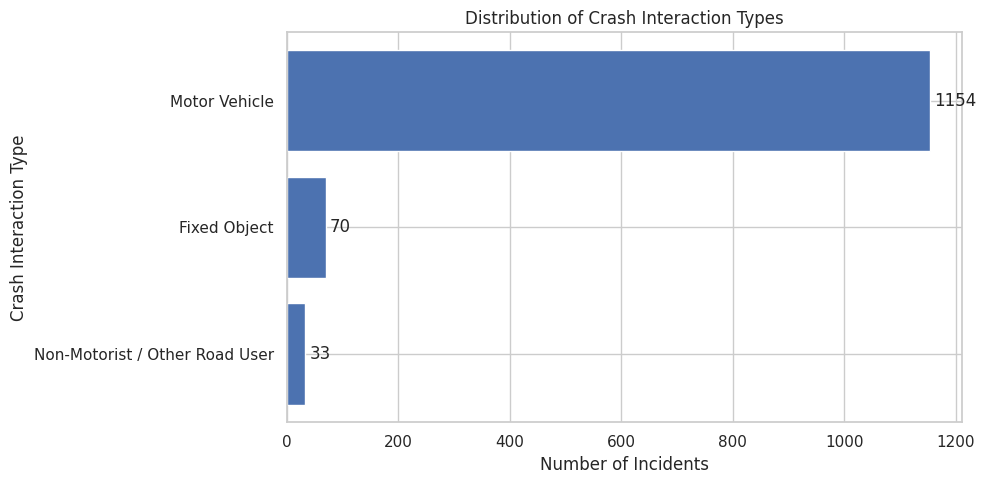

In [26]:
viz = IncidentVisualizer(cleaner.df)
viz.plot_crash_distribution()

### **Insight – Distribution of Crash Interaction Types**

**Takeaway:** RoboTaxi crashes are overwhelmingly collisions with other motor vehicles.

- **1,154 of 1,257** classified incidents (**91.8%**) involve another motor vehicle. Fixed objects account for **70 (5.6%)** and non-motorists / other road users for just **33 (2.6%)**.
- The target variable is **heavily imbalanced**: a model that always predicts "Motor Vehicle" would already be ~92% accurate. Later modelling should be judged with per-class recall / macro-F1 and use stratified splits, not accuracy alone.
- Non-motorist crashes are the rarest but arguably the most safety-critical. With only 33 cases, any pattern found for this class is *indicative*, not conclusive.


# Saving the cleaned Dataset

In [27]:
CLEANED_PATH = "autonomous_vehicle_incidents_cleaned.csv"
cleaner.save(CLEANED_PATH)

# **`Dataset Completeness Before and After Data Cleaning`**

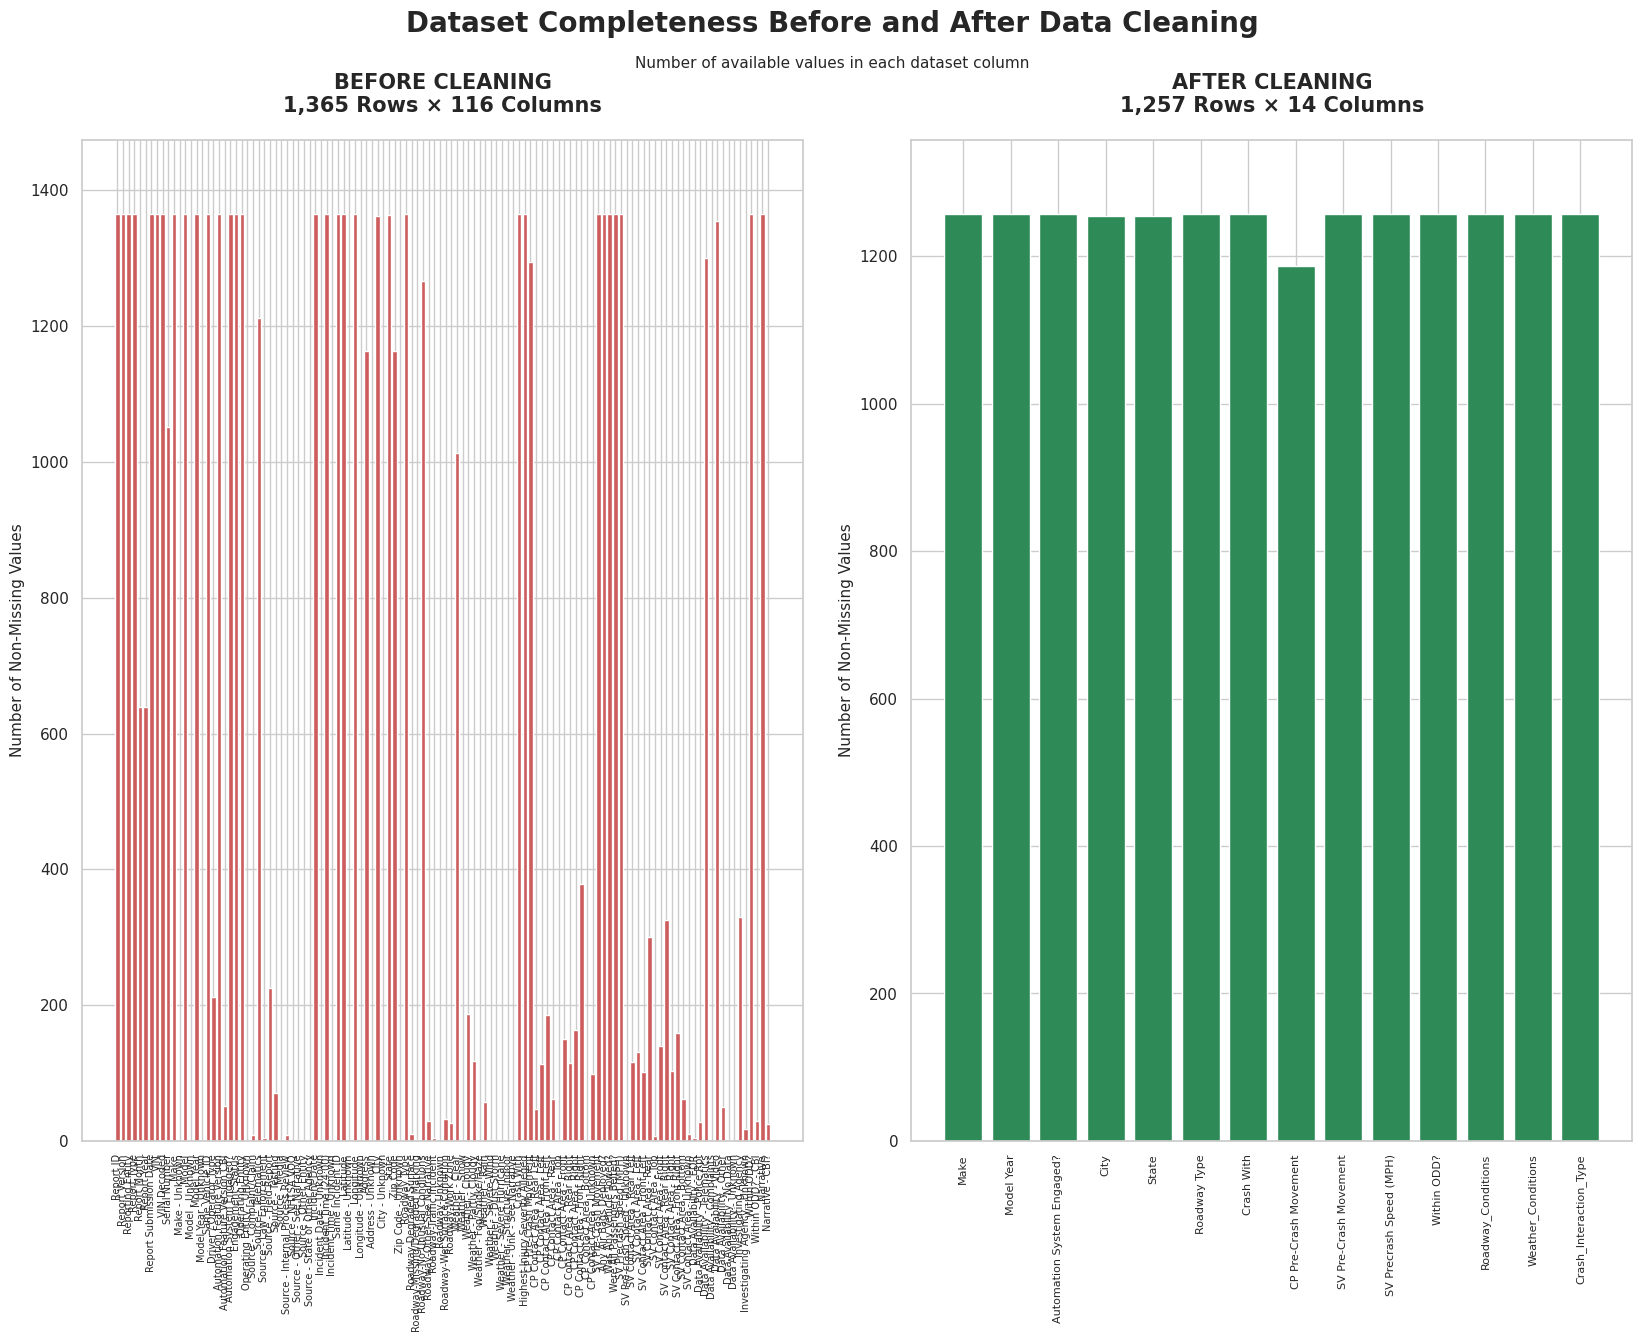

In [28]:
class DatasetCompletenessReport:
    def __init__(self, raw_path, cleaned_path):
        self.raw_path = raw_path
        self.cleaned_path = cleaned_path
        self.df_raw = None
        self.df_clean = None

    @staticmethod
    def _read(path):
        df = pd.read_csv(path)
        # Treat blank / whitespace-only strings as missing values.
        return df.replace(r"^\s*$", np.nan, regex=True)

    def load(self):
        self.df_raw = self._read(self.raw_path)
        self.df_clean = self._read(self.cleaned_path)
        return self

    @staticmethod
    def _draw_panel(ax, counts, n_rows, n_cols, title, color, tick_size):
        ax.bar(range(len(counts)), counts.values, color=color)

        ax.set_title(
            f"{title}\n{n_rows:,} Rows × {n_cols:,} Columns",
            fontsize=15,
            fontweight="bold",
            pad=20
        )

        ax.set_ylabel("Number of Non-Missing Values", fontsize=11)

        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=90, fontsize=tick_size)

        ax.set_ylim(0, n_rows * 1.08)

    def plot(self):
        raw_counts = self.df_raw.notna().sum()
        clean_counts = self.df_clean.notna().sum()

        fig, axes = plt.subplots(
            1, 2,
            figsize=(20, 13),
            gridspec_kw={"wspace": 0.15}
        )

        self._draw_panel(
            axes[0], raw_counts,
            self.df_raw.shape[0], self.df_raw.shape[1],
            "BEFORE CLEANING", "indianred", tick_size=7
        )
        self._draw_panel(
            axes[1], clean_counts,
            self.df_clean.shape[0], self.df_clean.shape[1],
            "AFTER CLEANING", "seagreen", tick_size=8
        )

        # Main title
        fig.suptitle(
            "Dataset Completeness Before and After Data Cleaning",
            fontsize=20,
            fontweight="bold",
            y=0.98
        )

        fig.text(
            0.5,
            0.935,
            "Number of available values in each dataset column",
            ha="center",
            fontsize=11
        )

        plt.tight_layout(rect=[0, 0.05, 1, 0.91])
        plt.show()


report = DatasetCompletenessReport(DATA_PATH, CLEANED_PATH).load()
report.plot()

df = report.df_clean

### **Insight – Dataset Completeness Before and After Cleaning**

**Takeaway:** Cleaning turned a sparse 116-column reporting file into a compact, almost fully populated 14-column analysis table.

- **Columns:** 116 → 14 (an 88% reduction). Before cleaning, most columns (contact areas, source flags, data-availability flags, CBI flags) are mostly empty, which likely reflects yes/no flag fields that are only filled in when they apply.
- **Rows:** 1,365 → 1,257. The 108 removed rows (7.9%) are the incidents whose "Crash With" value was *Other, see Narrative*, so they could not be classified without NLP.
- After cleaning, nearly every column is essentially complete, so **no imputation is needed** for the main variables.


# **Key Visuals and Insights**


### `Number of Incidents by Weather Conditions and Crash Interaction Type`

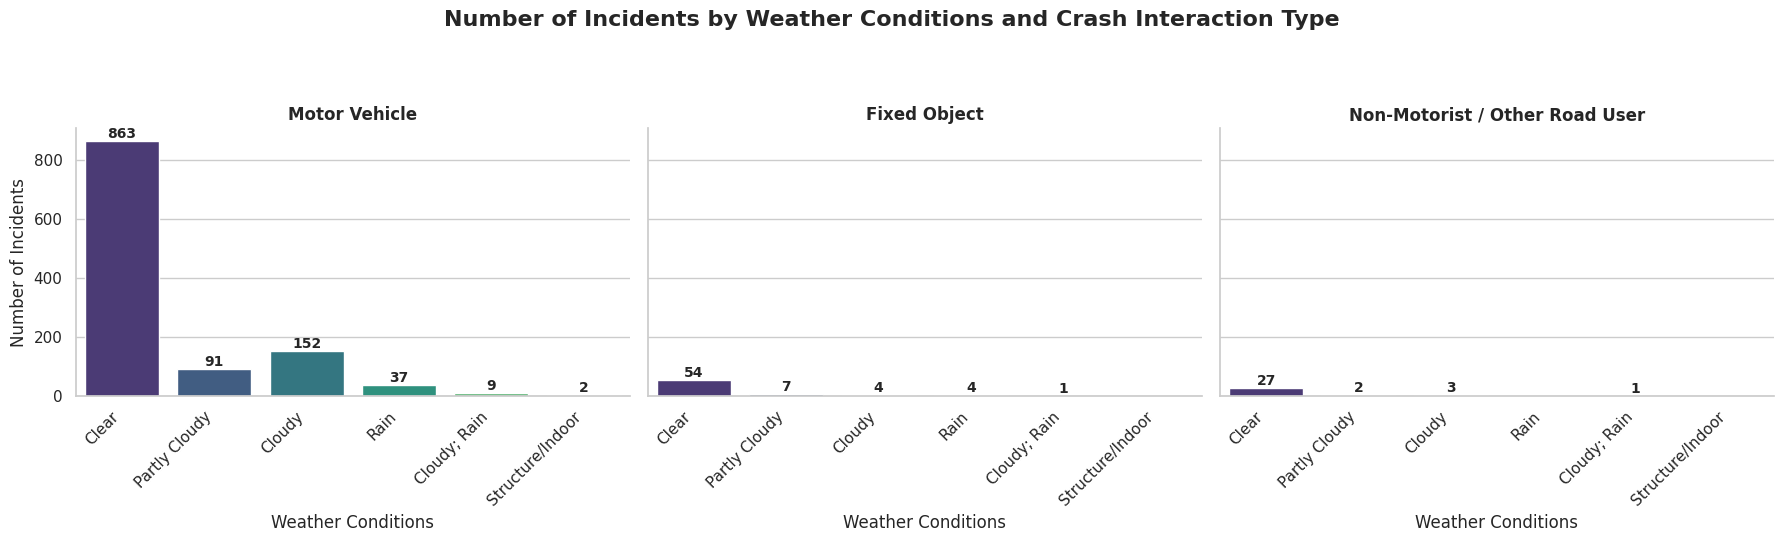

In [29]:
viz = IncidentVisualizer(df)
viz.plot_weather_counts()

### **Insight – Incidents by Weather Conditions and Crash Interaction Type**

**Takeaway:** Most crashes happen in clear weather, regardless of crash type. Bad weather is not the main environmental factor in this dataset.

- **Clear** conditions account for **944 of 1,257** incidents (75%): 863 motor vehicle, 54 fixed object, 27 non-motorist. Cloudy (159) and partly cloudy (100) follow; rain, alone or with cloud, accounts for only **52** incidents (≈4%).
- All three panels show the **same ranking** of weather conditions, so weather does not change *which* crash type dominates.
- No snow, fog/haze, severe wind or dust-storm incidents appear at all, which may reflect where and when the fleets operate.



# `Precrash Speed vs Crash Interaction Type`

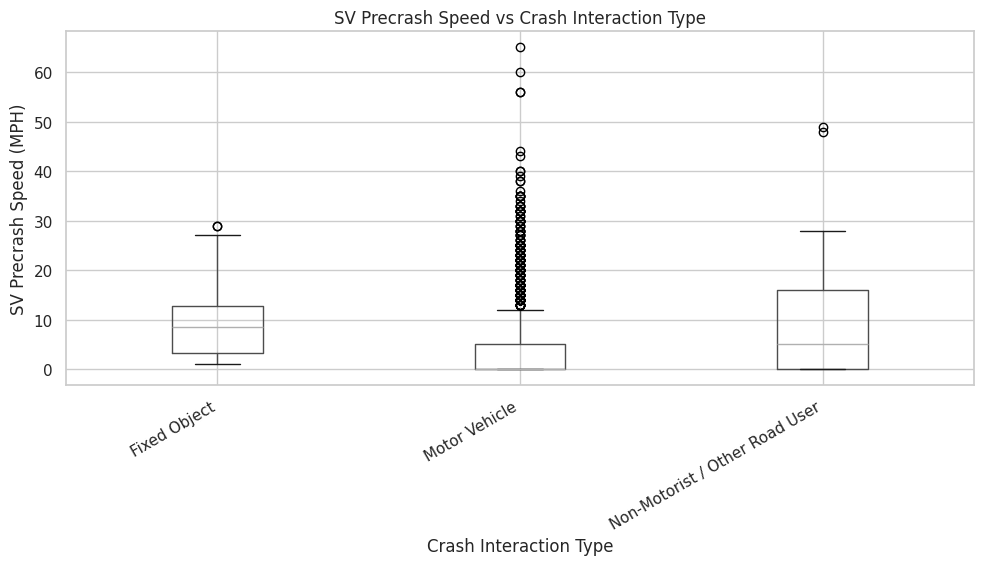

In [30]:
viz.plot_speed_boxplot()

### **Insight – SV Pre-Crash Speed vs Crash Interaction Type**

**Takeaway:** Crashes occur at low speeds, but fixed-object and non-motorist crashes happen at noticeably higher speeds than vehicle-to-vehicle crashes.

- **Motor Vehicle:** median of **0 mph** and a box that stops at ≈5 mph, so most of these crashes involve a stopped or creeping RoboTaxi. It has the *most* high-speed outliers (up to ≈65 mph), but they are the exception.
- **Fixed Object:** median of ≈**8–9 mph** and the minimum is above zero. The RoboTaxi is essentially always moving when it hits a fixed object, which makes physical sense.
- **Non-Motorist / Other:** median of ≈5 mph, but the widest box (up to ≈16 mph) and outliers near 48–49 mph. These are the highest-risk cases, although there are only 33 of them.
- Speed therefore helps separate crash types: a **stationary** RoboTaxi is almost always struck by another vehicle, while a **moving** one is more likely to hit an object or a non-motorist.


# `Crash Interaction by Roadway Type`

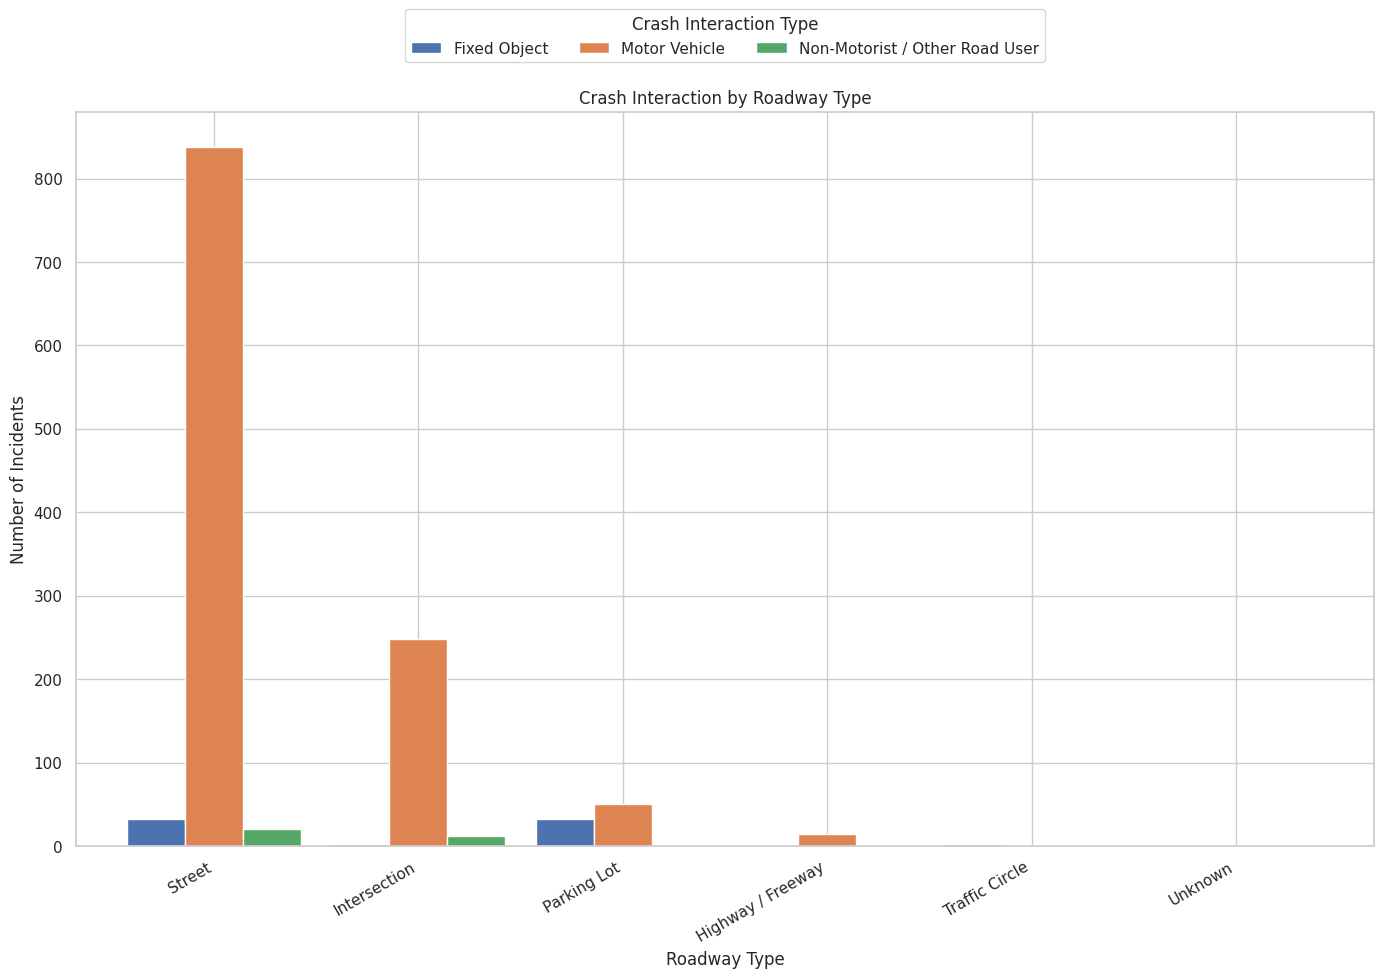

In [31]:
viz.plot_roadway_type()

### **Insight – Crash Interaction by Roadway Type**

**Takeaway:** Crashes cluster on ordinary streets and at intersections, and the roadway type changes the *kind* of crash that occurs. (Values below are read from the chart, so they are approximate.)

- **Street** (≈890 incidents, ~71%) and **Intersection** (≈265, ~21%) together account for about 9 in 10 crashes, and motor-vehicle collisions dominate both.
- **Parking lots** are only ≈7% of incidents (≈85), but fixed-object crashes are nearly as common as vehicle crashes there (≈33 vs ≈52). Roughly **half of all fixed-object crashes (≈33 of 70) happen in parking lots**.
- **Non-motorist crashes** appear only on streets (≈20) and at intersections (≈12), a slight over-representation at intersections relative to their ~21% share of all incidents.
- **Highway / freeway** incidents are few (≈15) and all involve other motor vehicles; traffic circles and unknown are negligible.
- Raw counts, not normalised by miles driven per road type.


# `Distribution of Reported SV Pre-Crash Speeds`

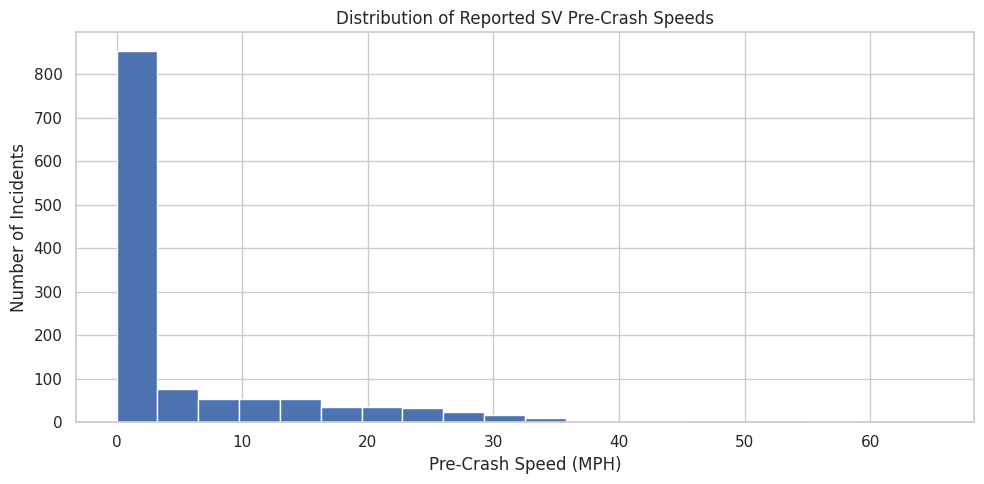

In [32]:
viz.plot_speed_histogram()

### **Insight – Distribution of Reported SV Pre-Crash Speeds**

**Takeaway:** The typical RoboTaxi crash happens at or near zero speed.

- The lowest bin (0 to ≈3 mph) holds about **850 of 1,257 incidents (roughly two-thirds)**, and the median is 0 mph.
- Frequency falls steadily as speed rises. Only a handful of incidents exceed 30 mph, a very few exceed 40, and the maximum is 65 mph.
- The distribution is strongly **right-skewed**: in the raw data the mean is ≈6.2 mph while the median is 0. For reporting, use the **median / quartiles rather than the mean**; for modelling, consider binning or transforming speed.
- Most reported crashes are therefore **low-energy events**, which links directly to the next chart (stopped and parked vehicles).


# `Crash Interaction by Pre-Crash Movement`

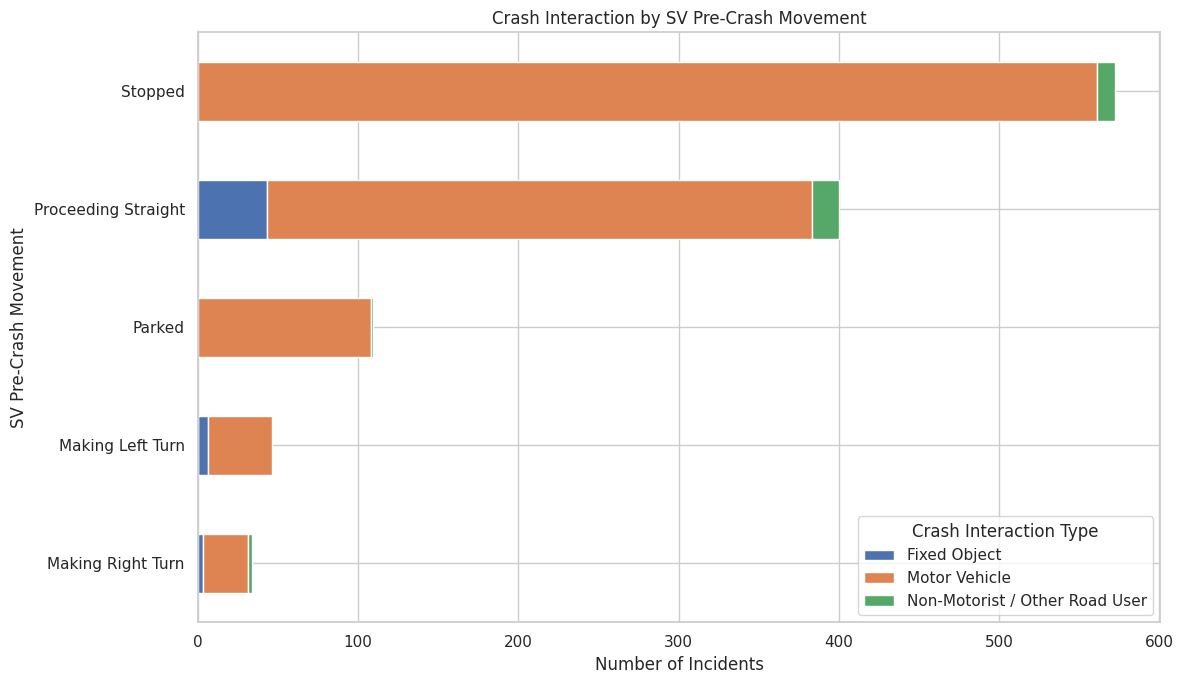

In [33]:
viz.plot_pre_crash_movement()

### **Insight – Crash Interaction by SV Pre-Crash Movement (Top 5 Movements)**

**Takeaway:** About half of all RoboTaxi crashes happen while the vehicle is stopped or parked, meaning it is usually the one being hit. (Values are read from the chart, so they are approximate.)

- **Stopped** (≈570, ~45% of all incidents) and **Parked** (≈110, ~9%) together make up roughly half of all crashes. The five movements shown cover about 92% of incidents.
- **Every parked crash, and almost every stopped crash, is with another motor vehicle.** Fixed-object crashes never occur while the vehicle is stopped or parked.
- **Proceeding straight** (≈400, ~32%) is the only movement with a meaningful mix of all three types, including ≈43 of the 70 fixed-object crashes and the largest share of non-motorist crashes.
- Turns (left ≈46, right ≈34) are comparatively rare.
- **Caution:** the dataset does not record fault. Stationary-vehicle crashes suggest that other road users often initiate contact, but this does not prove it.


# `Crash Interaction Composition Across Weather Conditions`

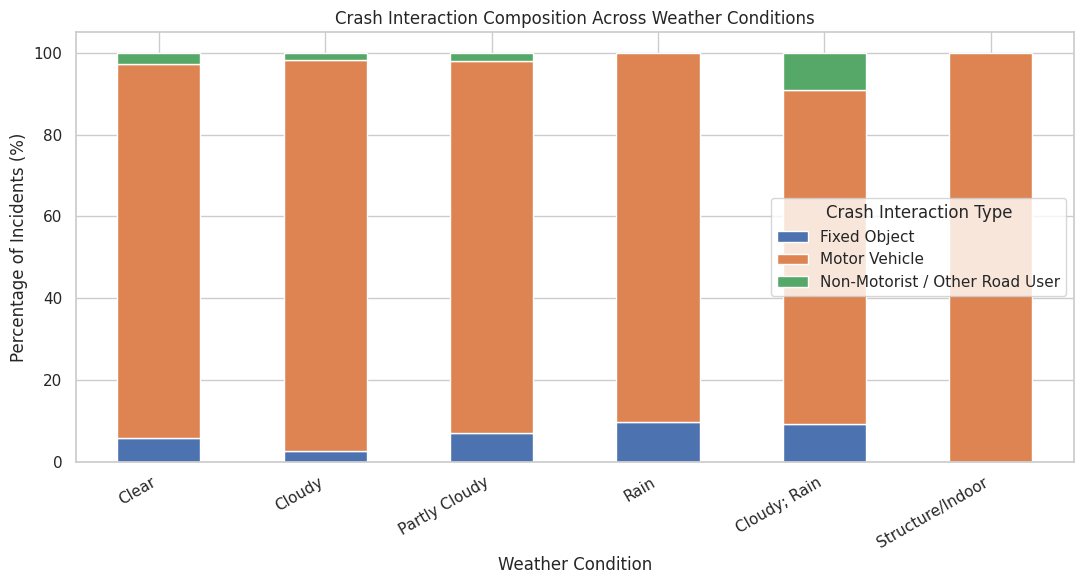

In [34]:
viz.plot_weather_composition()

### **Insight – Crash Interaction Composition Across Weather Conditions**

**Takeaway:** Once counts are converted to percentages, the crash-type mix barely changes with the weather, so weather is at most a weak factor.

- The **motor-vehicle share stays in a ~90–96% band** for clear (91%), partly cloudy (91%), cloudy (96%) and rain (90%).
- Rain shows a slightly higher fixed-object share (≈10%, 4 of 41) and Cloudy + Rain the highest non-motorist share (≈9%, 1 of 11). **These groups are tiny**: a single incident moves the percentage by 2 to 9 points, so the differences are not reliable. Structure/Indoor (n = 2) should be ignored.
- This supports the answer to the research question: **weather does not meaningfully separate crash types here**. A chi-square or Fisher exact test would be the natural next step to confirm it formally.


# `Mean Pre-crashed speed through Vehichle Model Year`

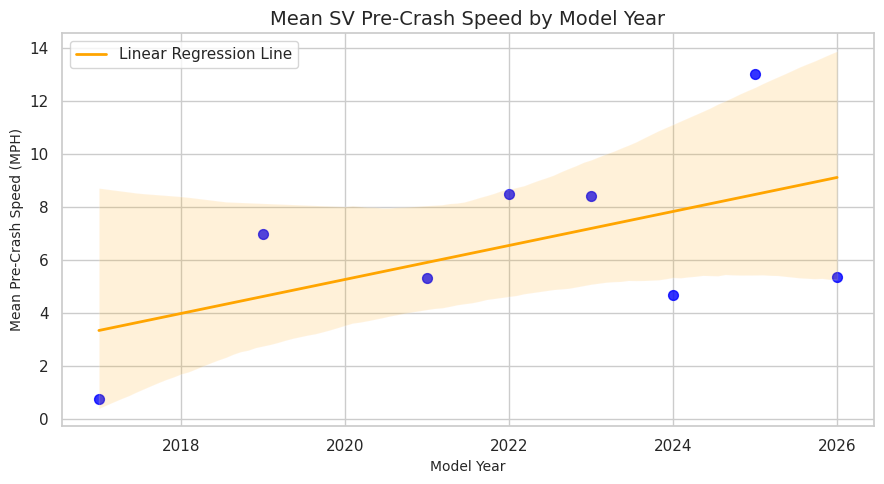

In [36]:
viz.plot_speed_by_model_year()

### **Insight – Mean SV Pre-Crash Speed by Model Year**

**Takeaway:** Newer model years show a slightly higher average pre-crash speed, but the trend is too weak and too noisy to rely on. (Values are read from the chart, so they are approximate.)



# Conclusion

## Final Insight

> **RoboTaxi crashes are mostly low-speed collisions with other motor vehicles, on city streets and at intersections, in clear weather. What separates one crash type from another is the roadway setting and what the RoboTaxi itself was doing (its movement and speed), not the weather.**

### Answer to the research question
*Which environmental and roadway factors are most associated with RoboTaxi crashes?*

| Factor | Association with crash interaction type | Strength |
|---|---|---|
| **SV pre-crash movement / speed** | Stopped or parked → almost only motor-vehicle crashes. Fixed-object crashes occur only while moving (median ≈8–9 mph). | **Strong** |
| **Roadway type** | Parking lots → fixed objects are ≈40% of crashes there (vs ≈4% on streets); intersections over-represent non-motorist crashes. | **Strong / moderate** |
| **Weather** | Crash-type mix is ~90–96% motor vehicle in every group with a meaningful sample. | **Weak** |
| **Vehicle model year** | Slight upward trend in mean pre-crash speed, but the confidence band is wide and older years have few incidents. | **Weak / inconclusive** |

### Key numbers
- **91.8%** of crashes involve another motor vehicle (1,154 of 1,257); fixed objects 5.6%; non-motorists 2.6%.
- **≈ two-thirds** of crashes happen at 0 to ≈3 mph, and the median pre-crash speed is **0 mph**.
- **≈ half** of crashes occur while the RoboTaxi is stopped or parked.
- **75%** of crashes occur in clear weather, and only ≈4% involve rain.

### What this means
- **Regulators / engineers:** focus on low-speed urban scenarios, such as being stopped at intersections or the curb and manoeuvring in parking lots (fixed obstacles). High-speed crashes are rare but are where the most extreme outliers sit.
- **Non-motorist crashes** are rare (33) but occur at higher speeds and mainly on streets and at intersections, so they deserve separate attention even though they are a small share.

### Limitations to state in the presentation
- **Counts, not rates:** there is no exposure data (miles driven, time in each condition), so "most crashes happen in clear weather" does not mean clear weather is riskier.
- **Reporting bias:** one operator (Waymo) accounts for about 82% of the raw reports (1,125 of 1,365).
- **Class imbalance:** 33 non-motorist and 70 fixed-object cases limit what can be concluded about them.
- **No fault information**, and 108 unclassified incidents ("Other, see Narrative") were excluded.
